# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [2]:
! git clone https://github.com/vcasadei/MNIST.git

Cloning into 'MNIST'...
remote: Enumerating objects: 10, done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 10 (from 1)
Receiving objects: 100% (10/10), 11.01 MiB | 13.06 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [3]:
!ls MNIST

processed  raw


In [4]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [5]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [6]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

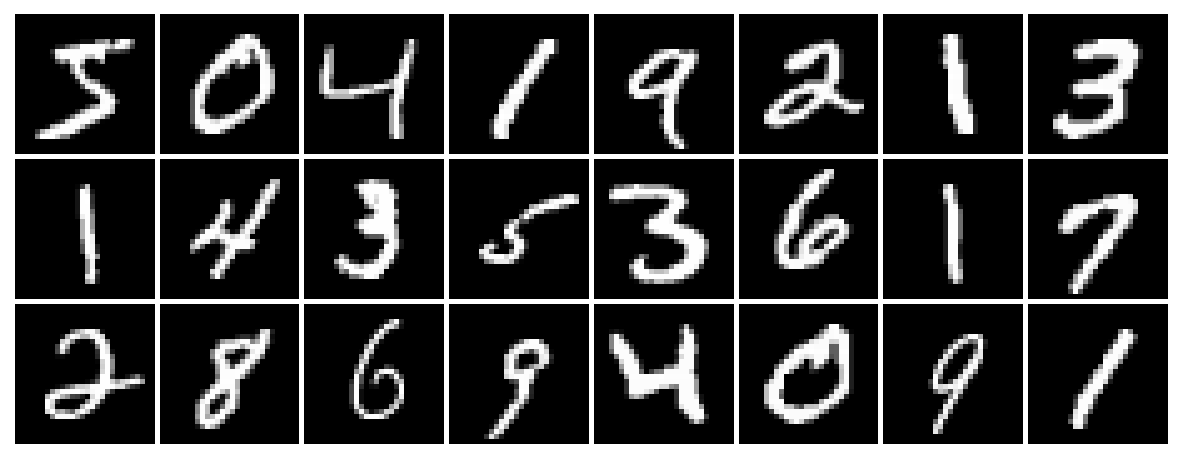

In [7]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


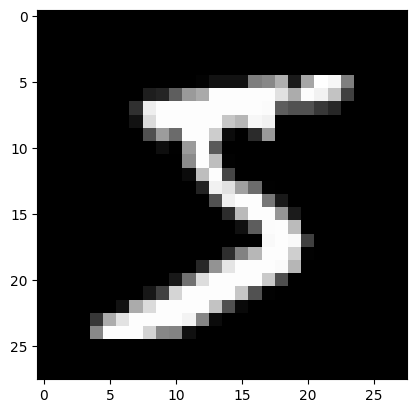

In [8]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [9]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [10]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[ 0.1874, -0.4861,  0.0835,  0.2032, -0.4667, -0.0331,  0.1045,  0.0281,
         -0.0467,  0.1123],
        [ 0.2924, -0.1558,  0.0163,  0.1553, -0.0948, -0.2093, -0.2617, -0.0626,
         -0.0041,  0.0596],
        [ 0.3418,  0.0556, -0.0174, -0.1473,  0.0219, -0.3427, -0.3637,  0.2971,
          0.0742, -0.2925],
        [ 0.2015, -0.0666, -0.1740,  0.0365, -0.5054,  0.0097, -0.2249, -0.0447,
         -0.1166, -0.0920],
        [ 0.1551, -0.0780,  0.0091,  0.1523, -0.1283, -0.0038,  0.0814, -0.3157,
         -0.4182, -0.1779]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [11]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [12]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

Epoch [1/100], Train Loss: 0.1061, Train Acc: 0.9890, Val Loss: 0.3228, Val Acc: 0.9100


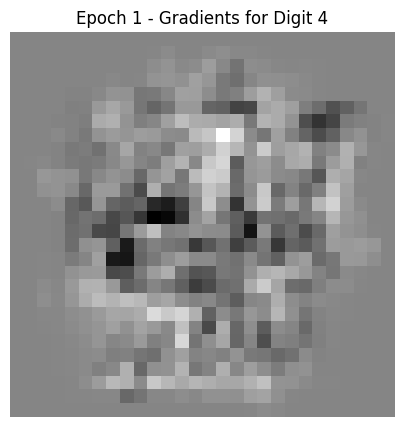

Epoch [2/100], Train Loss: 0.1058, Train Acc: 0.9890, Val Loss: 0.3227, Val Acc: 0.9100


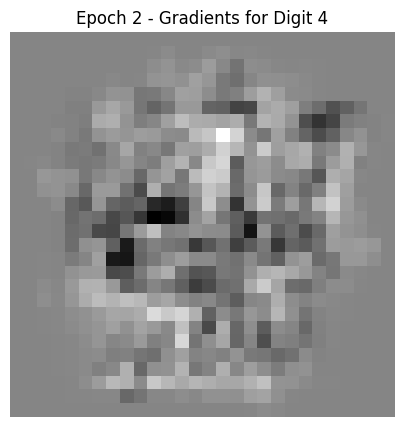

Epoch [3/100], Train Loss: 0.1056, Train Acc: 0.9890, Val Loss: 0.3227, Val Acc: 0.9100


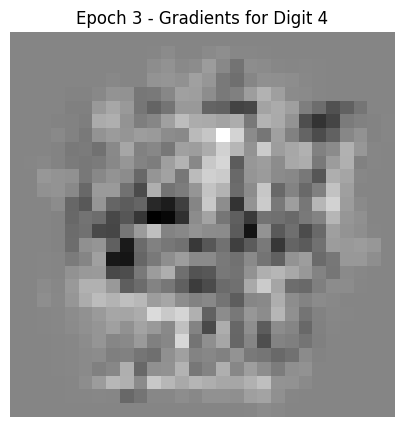

Epoch [4/100], Train Loss: 0.1054, Train Acc: 0.9890, Val Loss: 0.3226, Val Acc: 0.9100


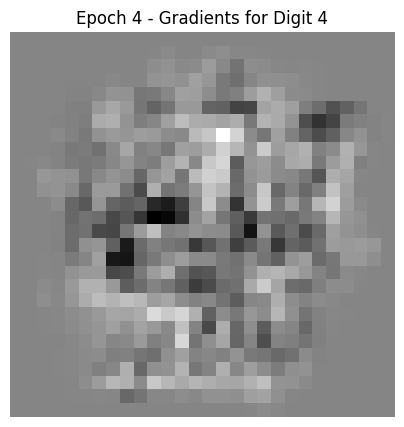

Epoch [5/100], Train Loss: 0.1052, Train Acc: 0.9890, Val Loss: 0.3225, Val Acc: 0.9100


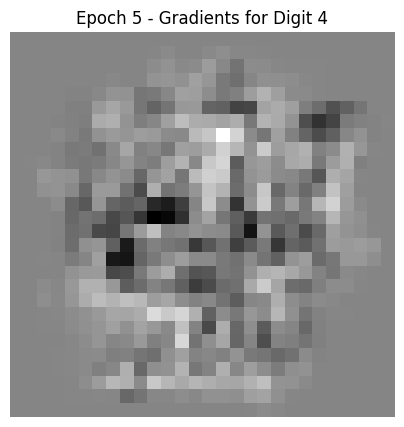

Epoch [6/100], Train Loss: 0.1050, Train Acc: 0.9890, Val Loss: 0.3225, Val Acc: 0.9100


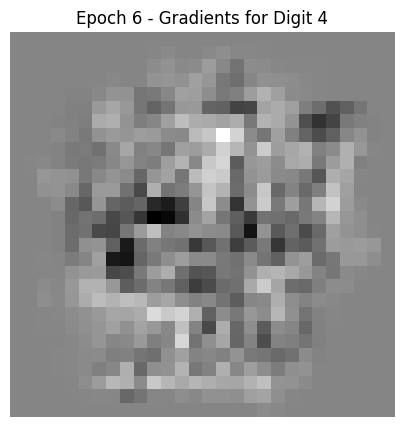

Epoch [7/100], Train Loss: 0.1047, Train Acc: 0.9890, Val Loss: 0.3224, Val Acc: 0.9100


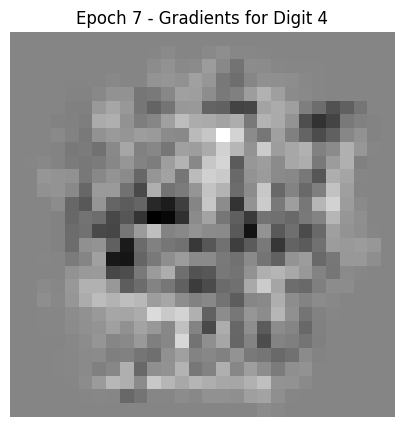

Epoch [8/100], Train Loss: 0.1045, Train Acc: 0.9890, Val Loss: 0.3224, Val Acc: 0.9100


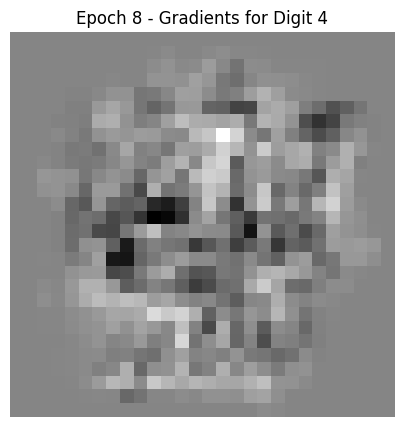

Epoch [9/100], Train Loss: 0.1043, Train Acc: 0.9900, Val Loss: 0.3223, Val Acc: 0.9100


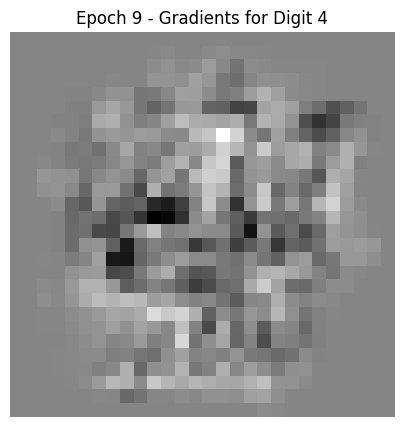

Epoch [10/100], Train Loss: 0.1041, Train Acc: 0.9900, Val Loss: 0.3223, Val Acc: 0.9100


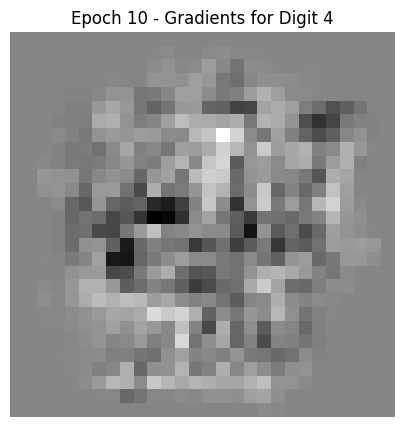

Epoch [11/100], Train Loss: 0.1039, Train Acc: 0.9900, Val Loss: 0.3222, Val Acc: 0.9100


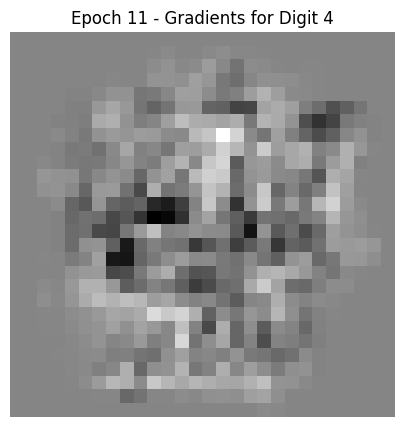

Epoch [12/100], Train Loss: 0.1037, Train Acc: 0.9910, Val Loss: 0.3222, Val Acc: 0.9100


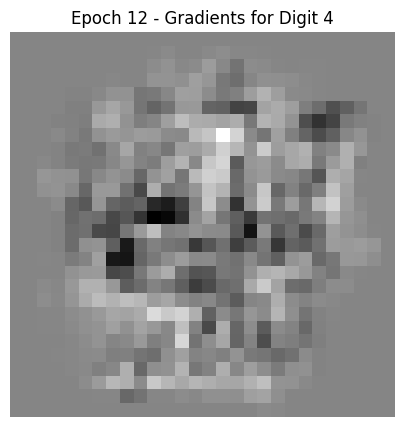

Epoch [13/100], Train Loss: 0.1034, Train Acc: 0.9910, Val Loss: 0.3221, Val Acc: 0.9100


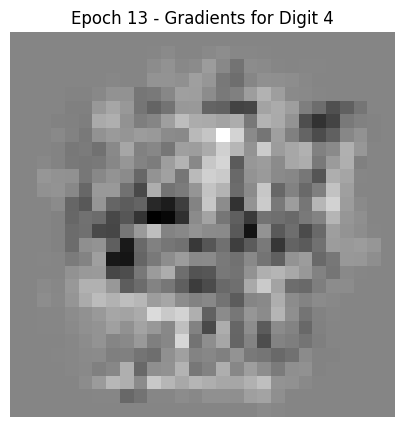

Epoch [14/100], Train Loss: 0.1032, Train Acc: 0.9910, Val Loss: 0.3220, Val Acc: 0.9100


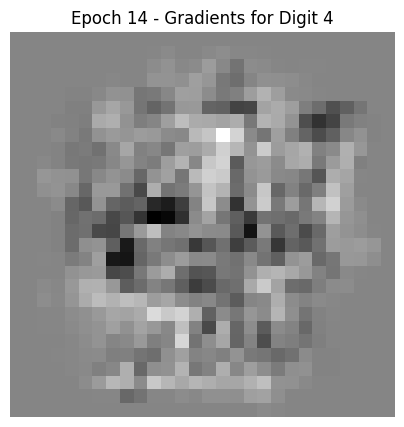

Epoch [15/100], Train Loss: 0.1030, Train Acc: 0.9910, Val Loss: 0.3220, Val Acc: 0.9100


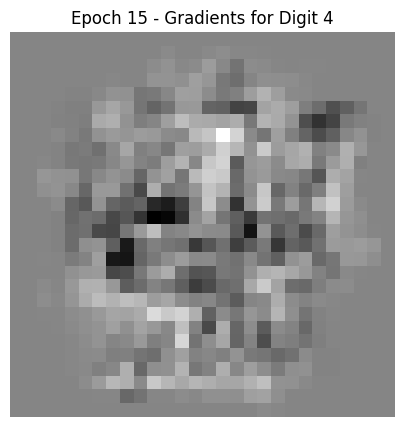

Epoch [16/100], Train Loss: 0.1028, Train Acc: 0.9910, Val Loss: 0.3219, Val Acc: 0.9100


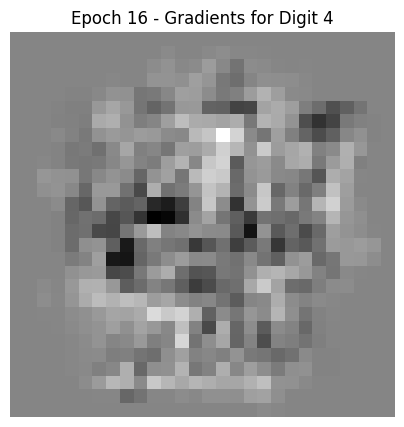

Epoch [17/100], Train Loss: 0.1026, Train Acc: 0.9920, Val Loss: 0.3219, Val Acc: 0.9100


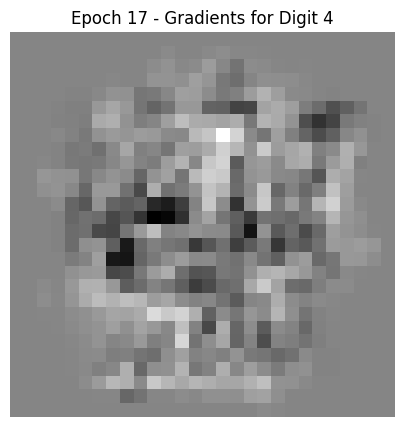

Epoch [18/100], Train Loss: 0.1024, Train Acc: 0.9920, Val Loss: 0.3218, Val Acc: 0.9100


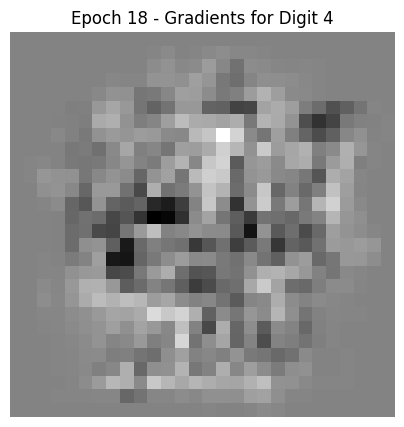

Epoch [19/100], Train Loss: 0.1022, Train Acc: 0.9920, Val Loss: 0.3218, Val Acc: 0.9100


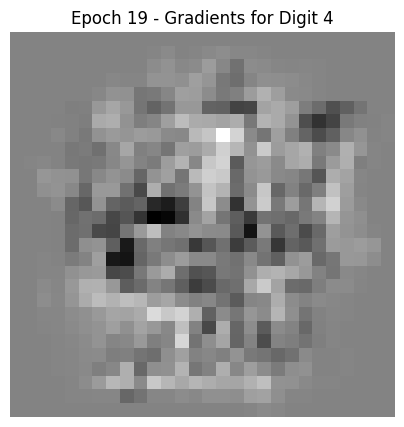

Epoch [20/100], Train Loss: 0.1020, Train Acc: 0.9930, Val Loss: 0.3217, Val Acc: 0.9100


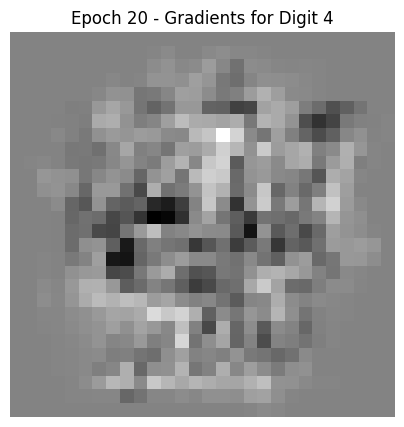

Epoch [21/100], Train Loss: 0.1018, Train Acc: 0.9930, Val Loss: 0.3217, Val Acc: 0.9100


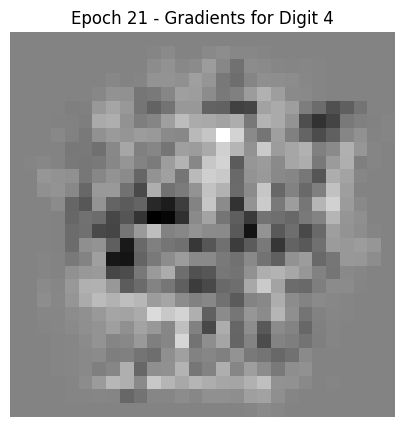

Epoch [22/100], Train Loss: 0.1016, Train Acc: 0.9930, Val Loss: 0.3216, Val Acc: 0.9100


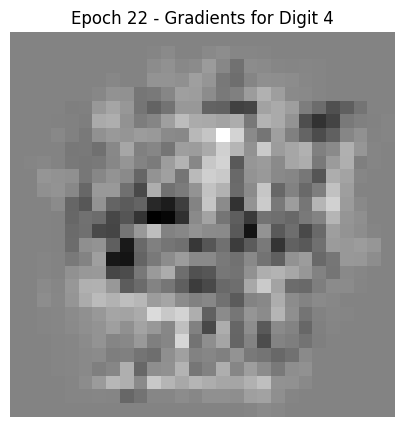

Epoch [23/100], Train Loss: 0.1013, Train Acc: 0.9930, Val Loss: 0.3216, Val Acc: 0.9100


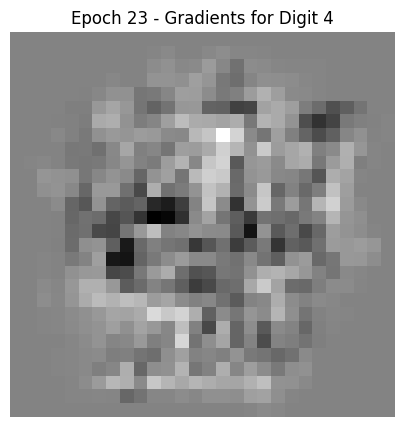

Epoch [24/100], Train Loss: 0.1011, Train Acc: 0.9930, Val Loss: 0.3215, Val Acc: 0.9100


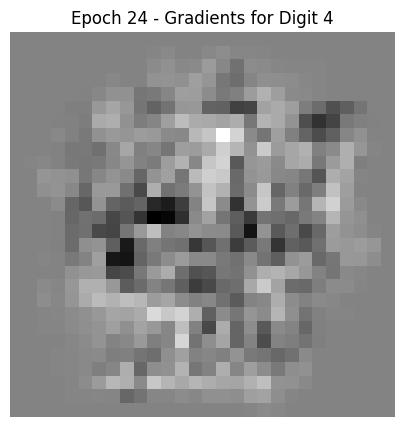

Epoch [25/100], Train Loss: 0.1009, Train Acc: 0.9930, Val Loss: 0.3215, Val Acc: 0.9100


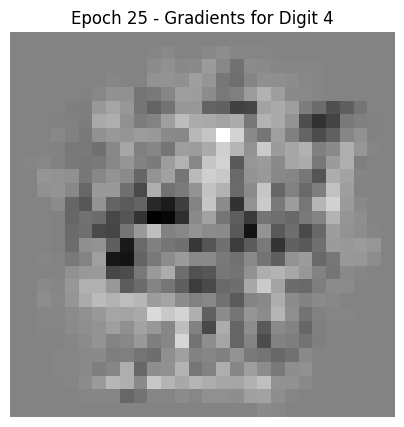

Epoch [26/100], Train Loss: 0.1007, Train Acc: 0.9930, Val Loss: 0.3214, Val Acc: 0.9100


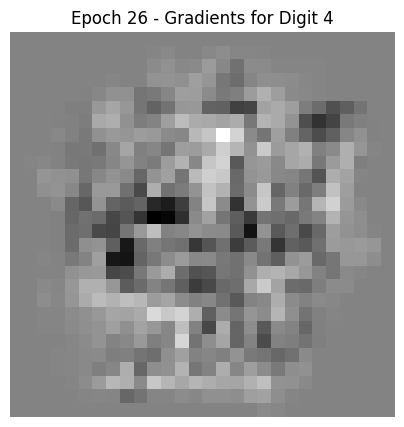

Epoch [27/100], Train Loss: 0.1005, Train Acc: 0.9930, Val Loss: 0.3214, Val Acc: 0.9100


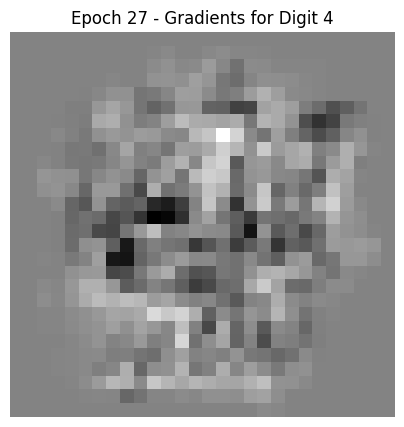

Epoch [28/100], Train Loss: 0.1003, Train Acc: 0.9930, Val Loss: 0.3213, Val Acc: 0.9100


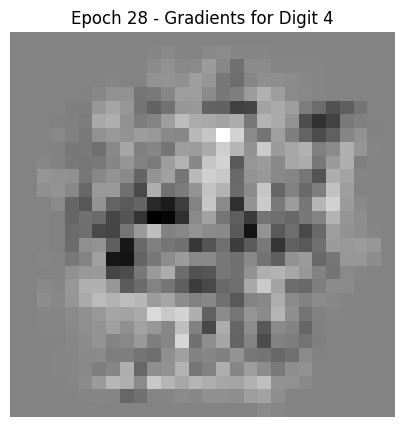

Epoch [29/100], Train Loss: 0.1001, Train Acc: 0.9930, Val Loss: 0.3213, Val Acc: 0.9100


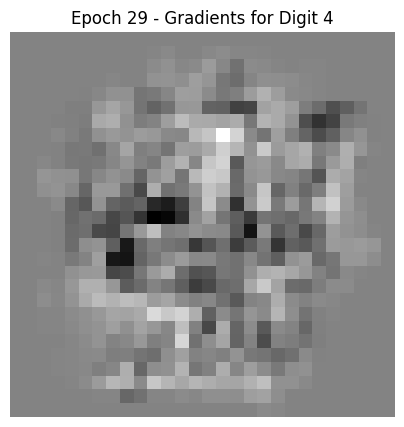

Epoch [30/100], Train Loss: 0.0999, Train Acc: 0.9930, Val Loss: 0.3212, Val Acc: 0.9100


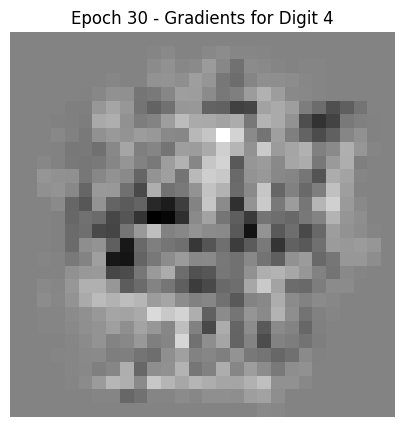

Epoch [31/100], Train Loss: 0.0997, Train Acc: 0.9930, Val Loss: 0.3212, Val Acc: 0.9100


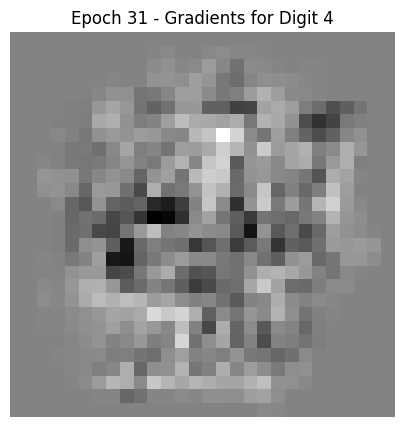

Epoch [32/100], Train Loss: 0.0995, Train Acc: 0.9930, Val Loss: 0.3211, Val Acc: 0.9100


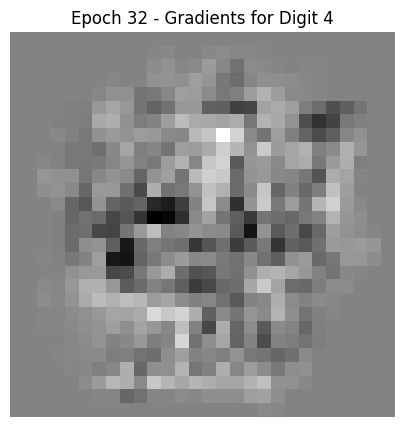

Epoch [33/100], Train Loss: 0.0993, Train Acc: 0.9930, Val Loss: 0.3211, Val Acc: 0.9100


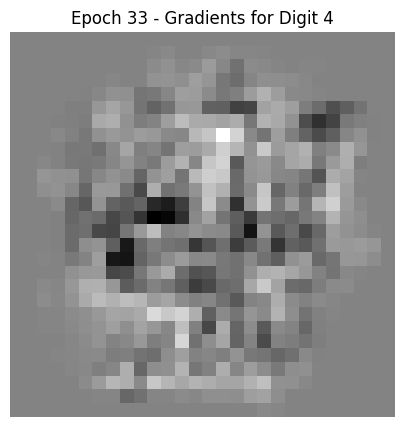

Epoch [34/100], Train Loss: 0.0991, Train Acc: 0.9930, Val Loss: 0.3210, Val Acc: 0.9100


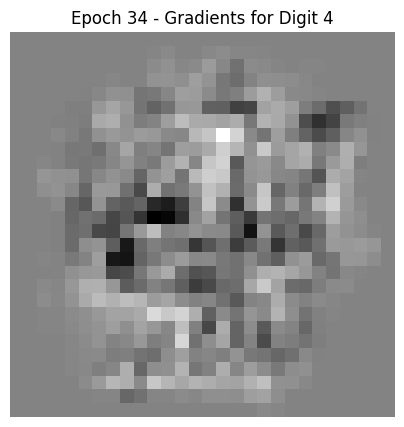

Epoch [35/100], Train Loss: 0.0989, Train Acc: 0.9940, Val Loss: 0.3210, Val Acc: 0.9100


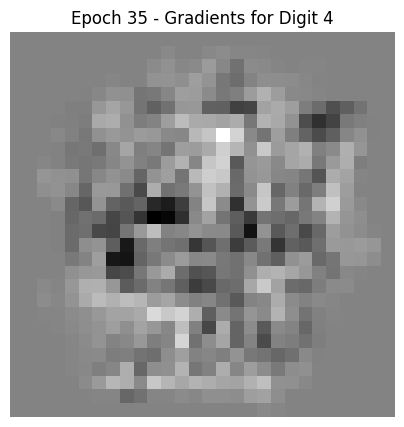

Epoch [36/100], Train Loss: 0.0987, Train Acc: 0.9940, Val Loss: 0.3209, Val Acc: 0.9100


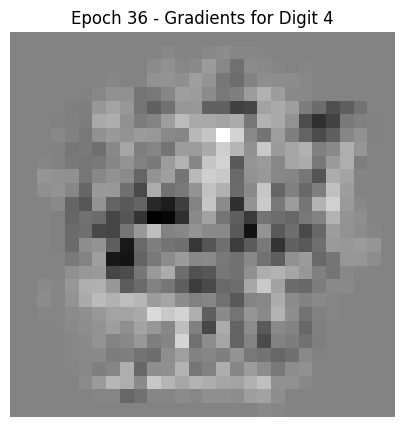

Epoch [37/100], Train Loss: 0.0985, Train Acc: 0.9940, Val Loss: 0.3209, Val Acc: 0.9100


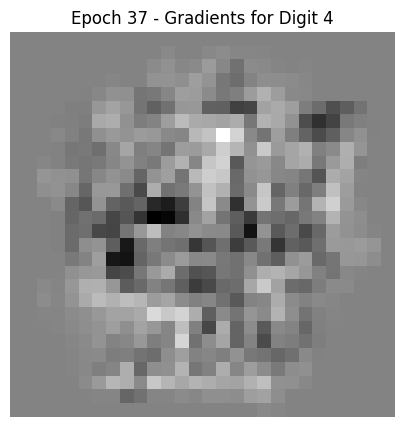

Epoch [38/100], Train Loss: 0.0984, Train Acc: 0.9940, Val Loss: 0.3208, Val Acc: 0.9100


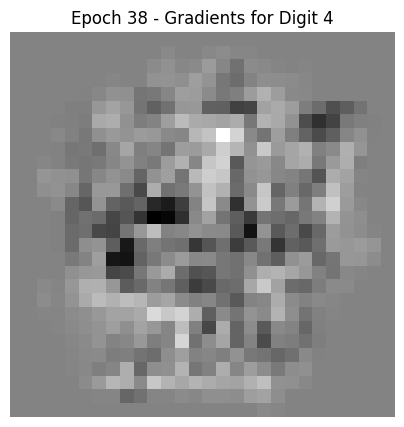

Epoch [39/100], Train Loss: 0.0982, Train Acc: 0.9940, Val Loss: 0.3208, Val Acc: 0.9100


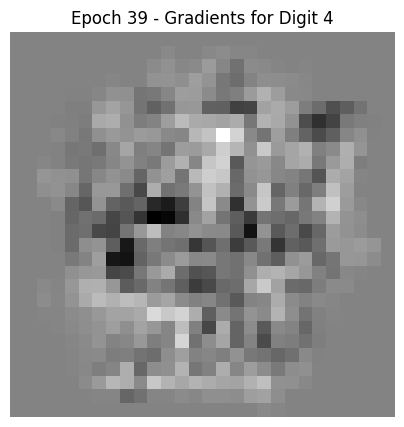

Epoch [40/100], Train Loss: 0.0980, Train Acc: 0.9940, Val Loss: 0.3208, Val Acc: 0.9100


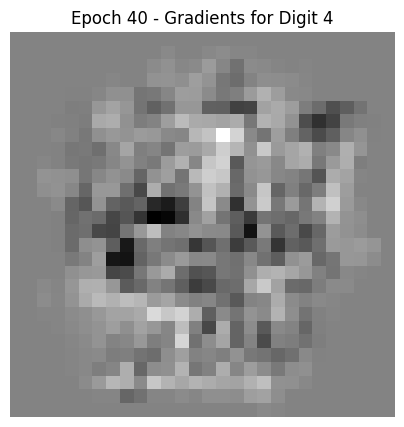

Epoch [41/100], Train Loss: 0.0978, Train Acc: 0.9940, Val Loss: 0.3207, Val Acc: 0.9100


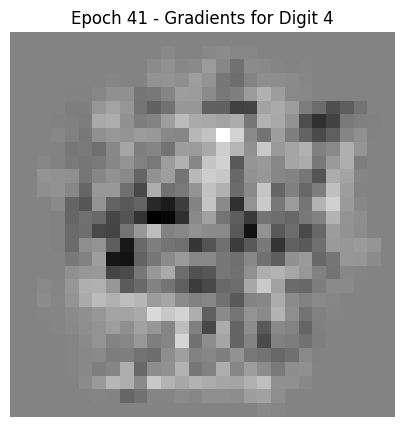

Epoch [42/100], Train Loss: 0.0976, Train Acc: 0.9940, Val Loss: 0.3207, Val Acc: 0.9100


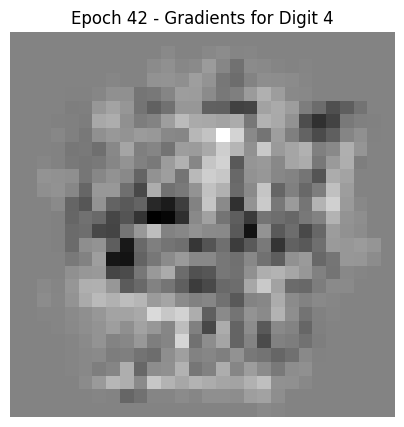

Epoch [43/100], Train Loss: 0.0974, Train Acc: 0.9940, Val Loss: 0.3206, Val Acc: 0.9100


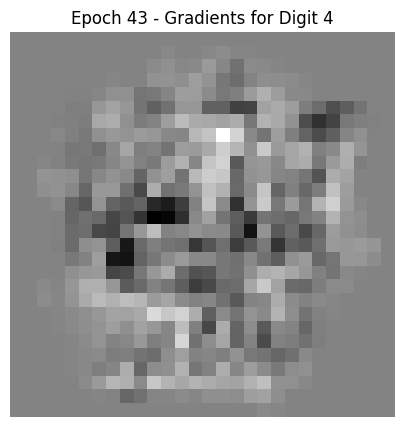

Epoch [44/100], Train Loss: 0.0972, Train Acc: 0.9940, Val Loss: 0.3206, Val Acc: 0.9100


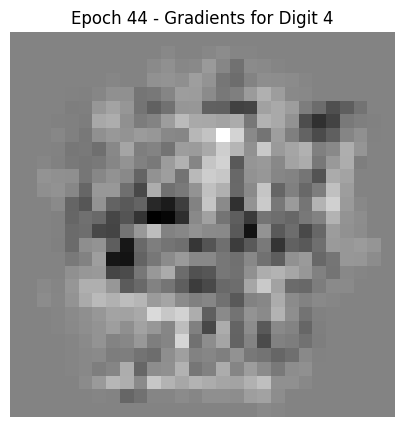

Epoch [45/100], Train Loss: 0.0970, Train Acc: 0.9940, Val Loss: 0.3205, Val Acc: 0.9100


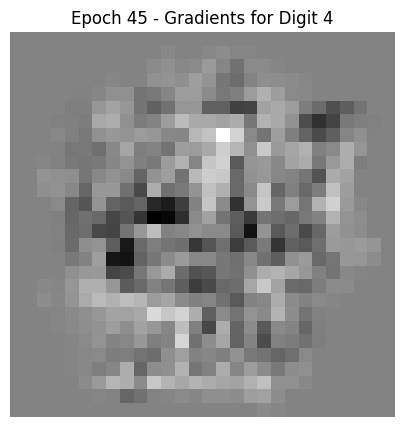

Epoch [46/100], Train Loss: 0.0968, Train Acc: 0.9940, Val Loss: 0.3205, Val Acc: 0.9100


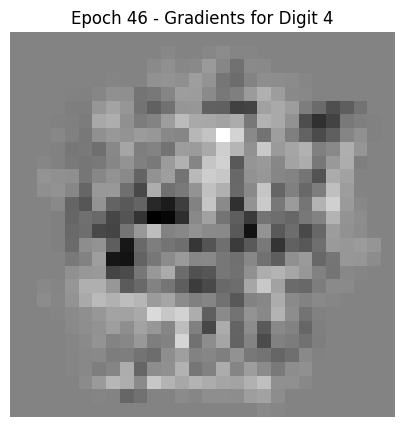

Epoch [47/100], Train Loss: 0.0966, Train Acc: 0.9940, Val Loss: 0.3204, Val Acc: 0.9100


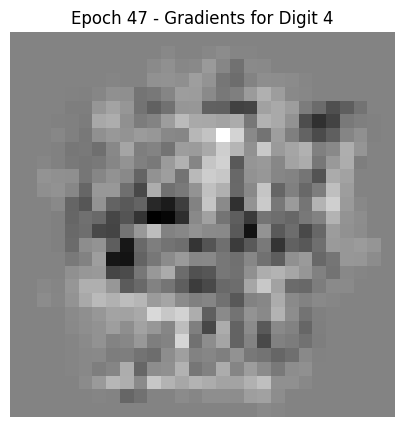

Epoch [48/100], Train Loss: 0.0964, Train Acc: 0.9940, Val Loss: 0.3204, Val Acc: 0.9100


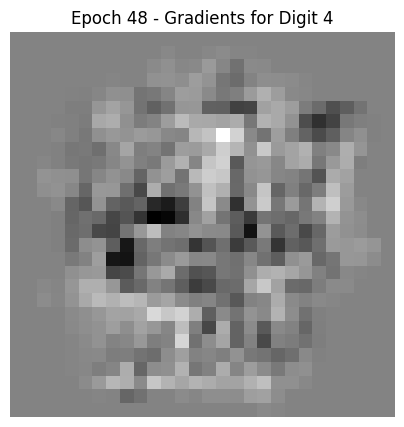

Epoch [49/100], Train Loss: 0.0963, Train Acc: 0.9940, Val Loss: 0.3203, Val Acc: 0.9100


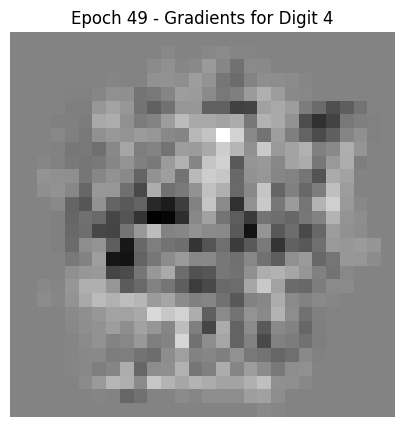

Epoch [50/100], Train Loss: 0.0961, Train Acc: 0.9940, Val Loss: 0.3203, Val Acc: 0.9100


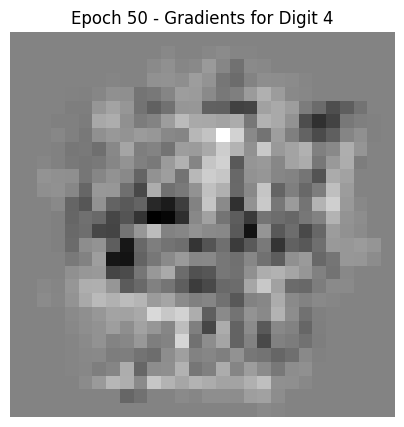

Epoch [51/100], Train Loss: 0.0959, Train Acc: 0.9940, Val Loss: 0.3203, Val Acc: 0.9100


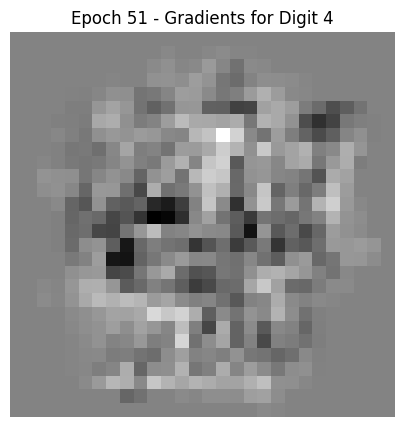

Epoch [52/100], Train Loss: 0.0957, Train Acc: 0.9940, Val Loss: 0.3202, Val Acc: 0.9100


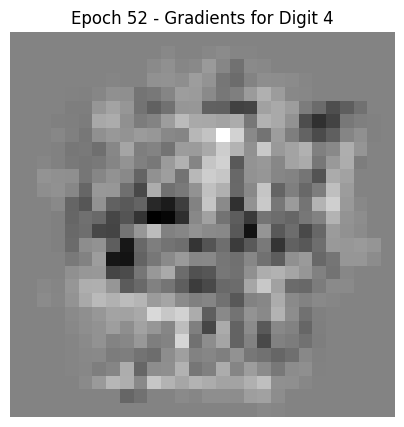

Epoch [53/100], Train Loss: 0.0955, Train Acc: 0.9940, Val Loss: 0.3202, Val Acc: 0.9100


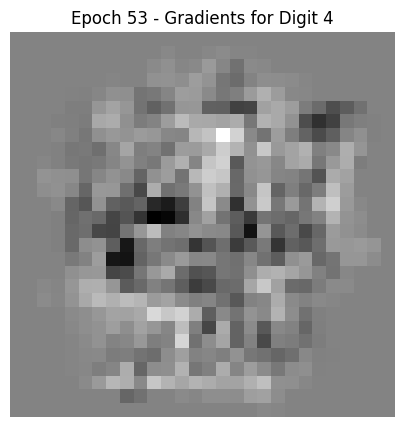

Epoch [54/100], Train Loss: 0.0953, Train Acc: 0.9940, Val Loss: 0.3201, Val Acc: 0.9100


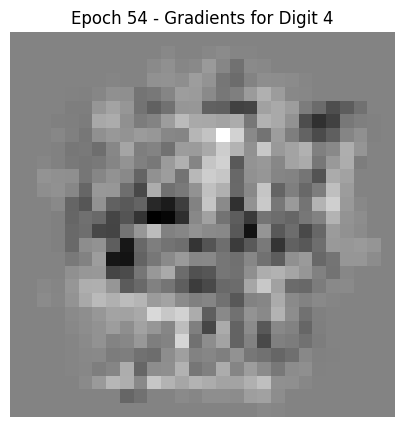

Epoch [55/100], Train Loss: 0.0951, Train Acc: 0.9940, Val Loss: 0.3201, Val Acc: 0.9100


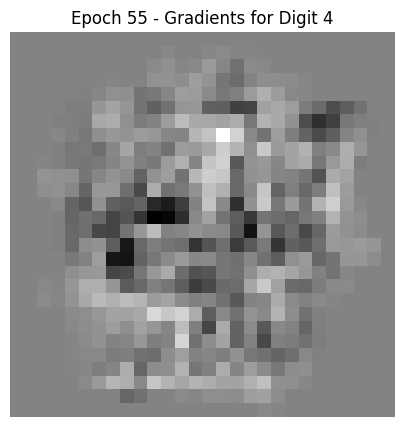

Epoch [56/100], Train Loss: 0.0950, Train Acc: 0.9940, Val Loss: 0.3200, Val Acc: 0.9100


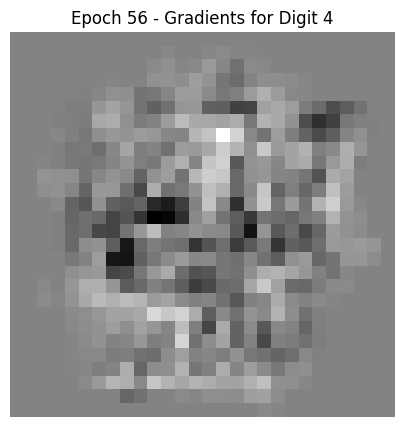

Epoch [57/100], Train Loss: 0.0948, Train Acc: 0.9940, Val Loss: 0.3200, Val Acc: 0.9100


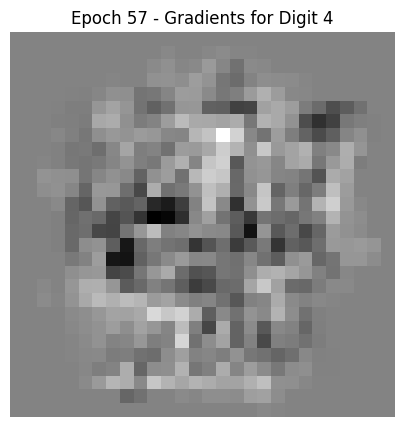

Epoch [58/100], Train Loss: 0.0946, Train Acc: 0.9940, Val Loss: 0.3200, Val Acc: 0.9100


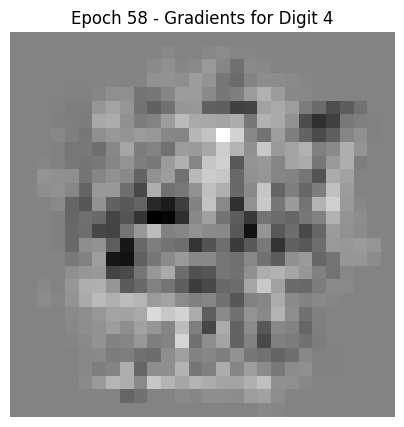

Epoch [59/100], Train Loss: 0.0944, Train Acc: 0.9940, Val Loss: 0.3199, Val Acc: 0.9100


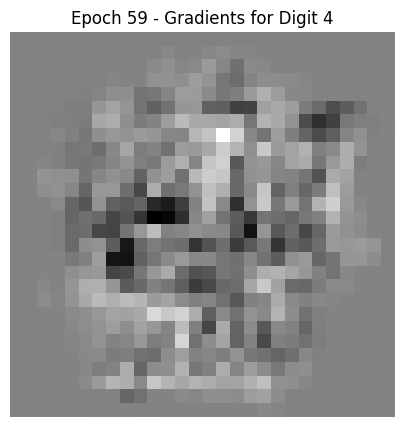

Epoch [60/100], Train Loss: 0.0942, Train Acc: 0.9940, Val Loss: 0.3199, Val Acc: 0.9100


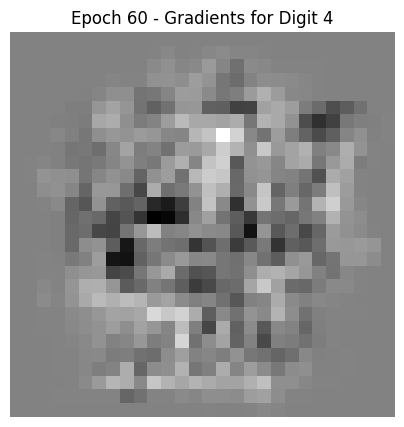

Epoch [61/100], Train Loss: 0.0941, Train Acc: 0.9940, Val Loss: 0.3198, Val Acc: 0.9100


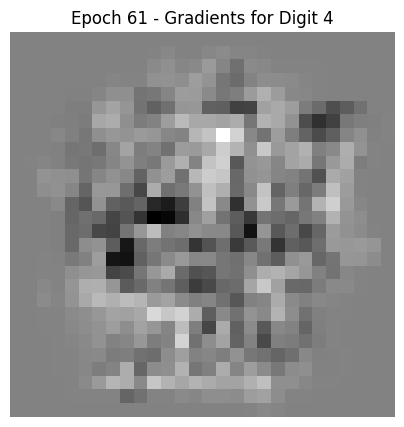

Epoch [62/100], Train Loss: 0.0939, Train Acc: 0.9940, Val Loss: 0.3198, Val Acc: 0.9100


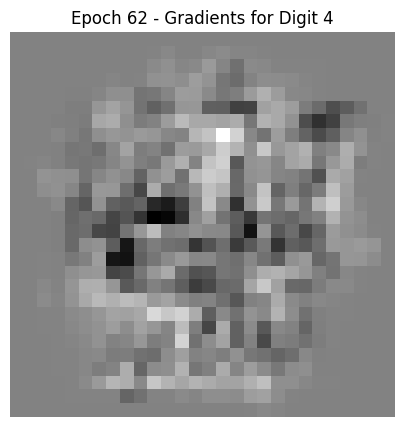

Epoch [63/100], Train Loss: 0.0937, Train Acc: 0.9940, Val Loss: 0.3198, Val Acc: 0.9100


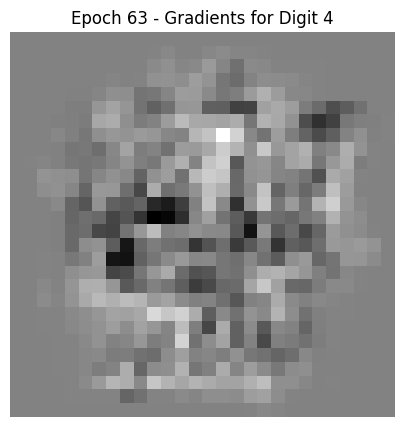

Epoch [64/100], Train Loss: 0.0935, Train Acc: 0.9940, Val Loss: 0.3197, Val Acc: 0.9100


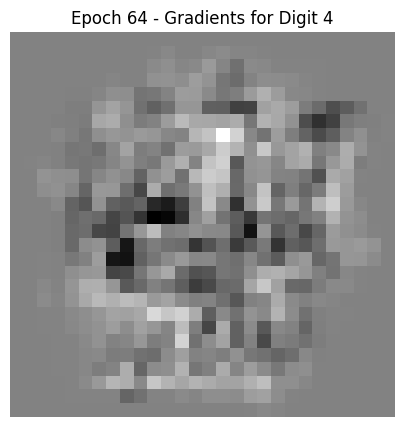

Epoch [65/100], Train Loss: 0.0933, Train Acc: 0.9940, Val Loss: 0.3197, Val Acc: 0.9100


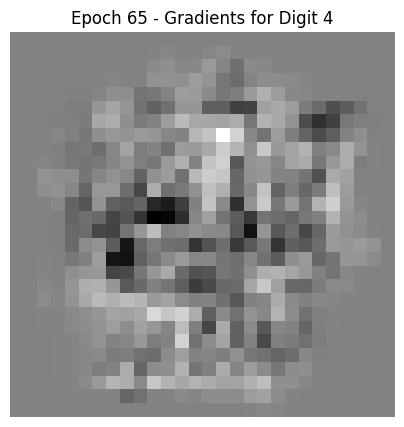

Epoch [66/100], Train Loss: 0.0932, Train Acc: 0.9940, Val Loss: 0.3196, Val Acc: 0.9100


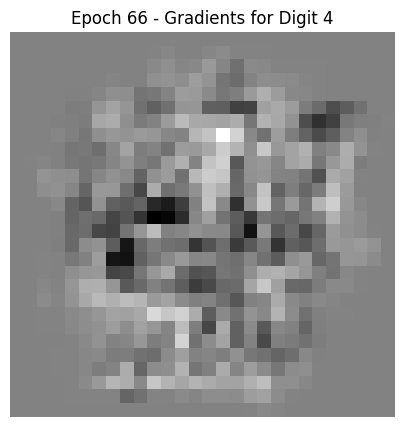

Epoch [67/100], Train Loss: 0.0930, Train Acc: 0.9940, Val Loss: 0.3196, Val Acc: 0.9100


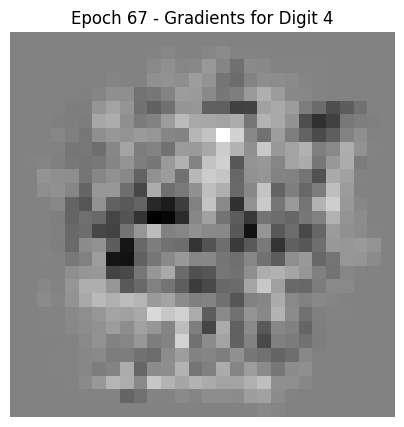

Epoch [68/100], Train Loss: 0.0928, Train Acc: 0.9940, Val Loss: 0.3195, Val Acc: 0.9100


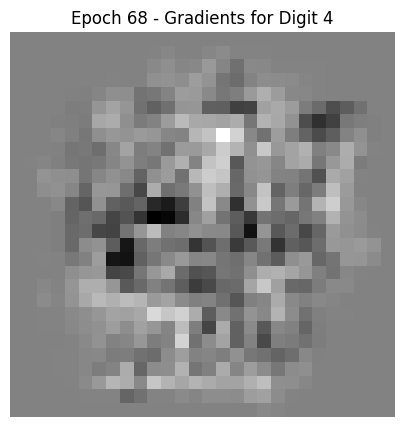

Epoch [69/100], Train Loss: 0.0926, Train Acc: 0.9940, Val Loss: 0.3195, Val Acc: 0.9100


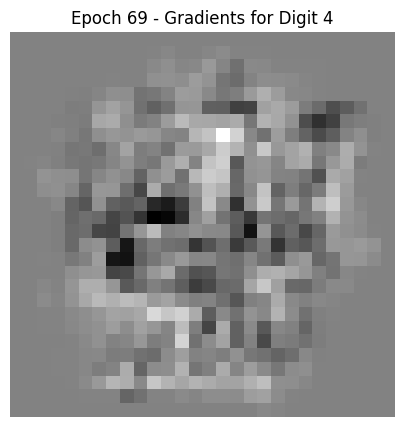

Epoch [70/100], Train Loss: 0.0925, Train Acc: 0.9950, Val Loss: 0.3195, Val Acc: 0.9100


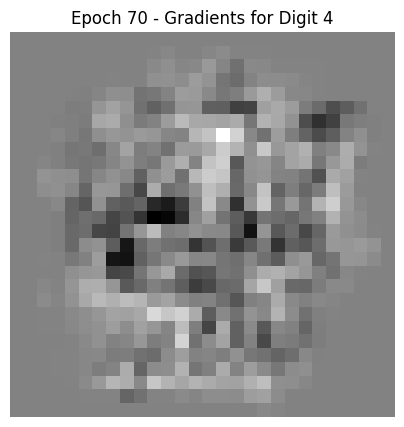

Epoch [71/100], Train Loss: 0.0923, Train Acc: 0.9950, Val Loss: 0.3194, Val Acc: 0.9100


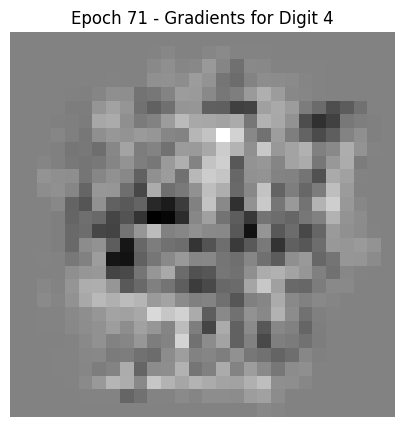

Epoch [72/100], Train Loss: 0.0921, Train Acc: 0.9950, Val Loss: 0.3194, Val Acc: 0.9100


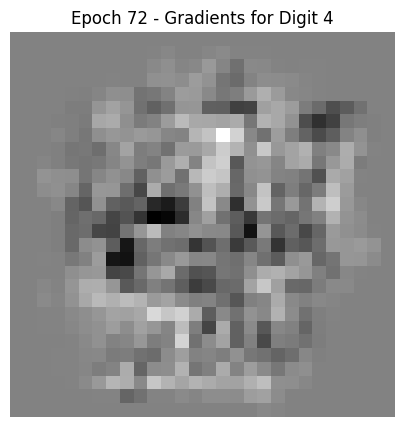

Epoch [73/100], Train Loss: 0.0919, Train Acc: 0.9950, Val Loss: 0.3194, Val Acc: 0.9100


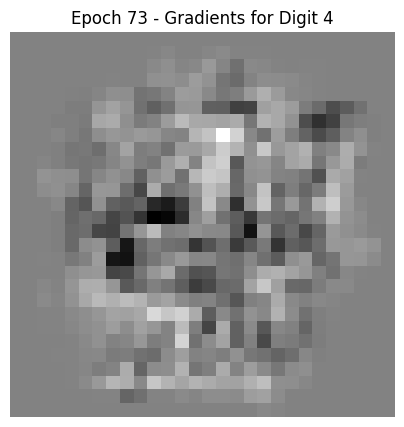

Epoch [74/100], Train Loss: 0.0918, Train Acc: 0.9950, Val Loss: 0.3193, Val Acc: 0.9100


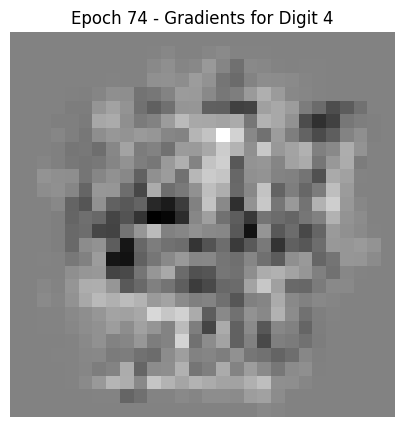

Epoch [75/100], Train Loss: 0.0916, Train Acc: 0.9950, Val Loss: 0.3193, Val Acc: 0.9100


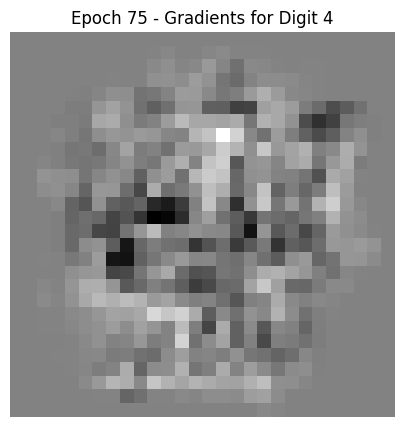

Epoch [76/100], Train Loss: 0.0914, Train Acc: 0.9950, Val Loss: 0.3192, Val Acc: 0.9100


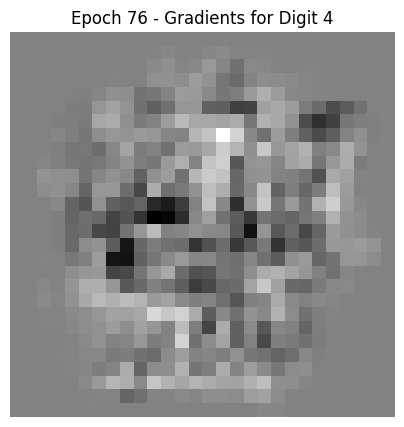

Epoch [77/100], Train Loss: 0.0913, Train Acc: 0.9950, Val Loss: 0.3192, Val Acc: 0.9100


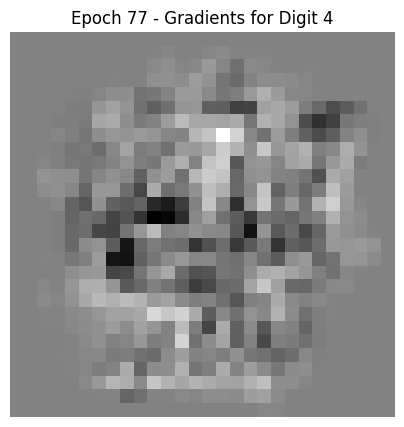

Epoch [78/100], Train Loss: 0.0911, Train Acc: 0.9950, Val Loss: 0.3192, Val Acc: 0.9100


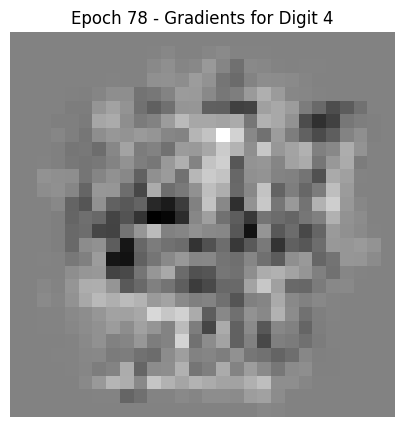

Epoch [79/100], Train Loss: 0.0909, Train Acc: 0.9950, Val Loss: 0.3191, Val Acc: 0.9100


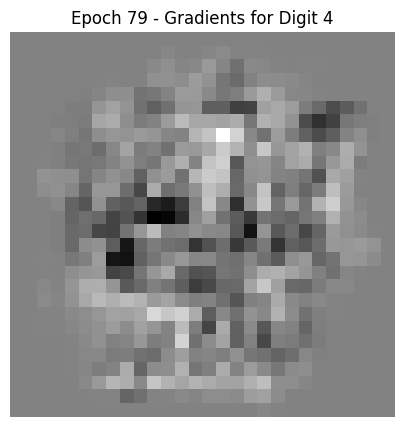

Epoch [80/100], Train Loss: 0.0908, Train Acc: 0.9950, Val Loss: 0.3191, Val Acc: 0.9100


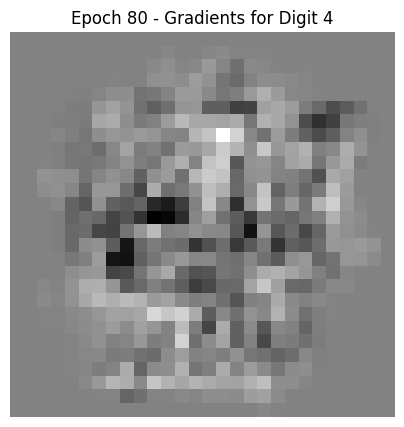

Epoch [81/100], Train Loss: 0.0906, Train Acc: 0.9950, Val Loss: 0.3190, Val Acc: 0.9100


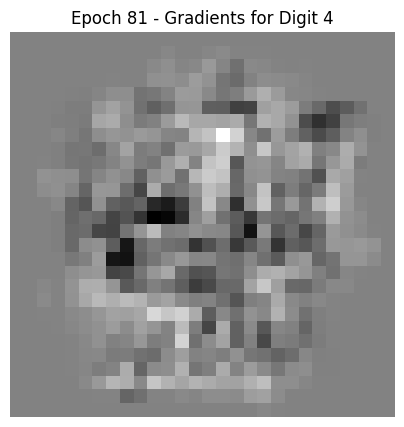

Epoch [82/100], Train Loss: 0.0904, Train Acc: 0.9950, Val Loss: 0.3190, Val Acc: 0.9100


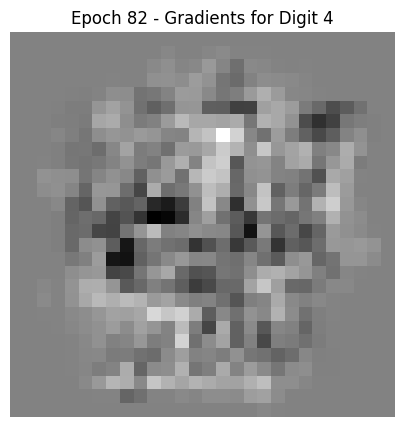

Epoch [83/100], Train Loss: 0.0903, Train Acc: 0.9950, Val Loss: 0.3190, Val Acc: 0.9100


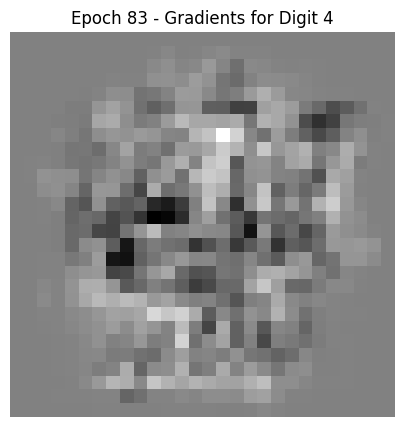

Epoch [84/100], Train Loss: 0.0901, Train Acc: 0.9950, Val Loss: 0.3189, Val Acc: 0.9100


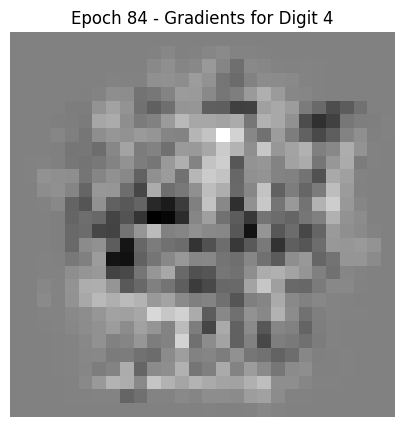

Epoch [85/100], Train Loss: 0.0899, Train Acc: 0.9950, Val Loss: 0.3189, Val Acc: 0.9100


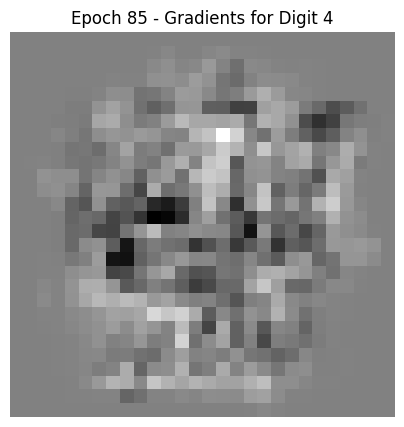

Epoch [86/100], Train Loss: 0.0898, Train Acc: 0.9950, Val Loss: 0.3189, Val Acc: 0.9100


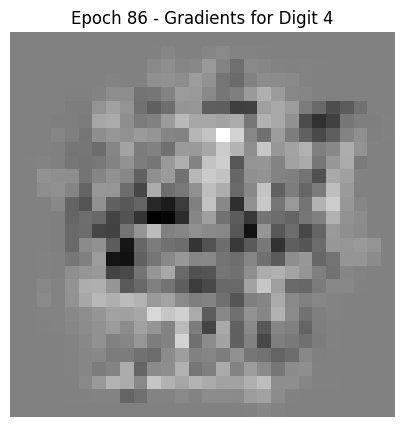

Epoch [87/100], Train Loss: 0.0896, Train Acc: 0.9950, Val Loss: 0.3188, Val Acc: 0.9050


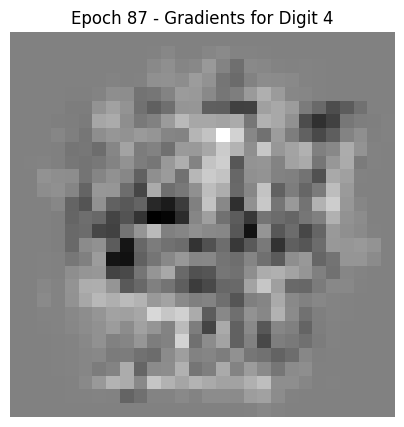

Epoch [88/100], Train Loss: 0.0894, Train Acc: 0.9950, Val Loss: 0.3188, Val Acc: 0.9050


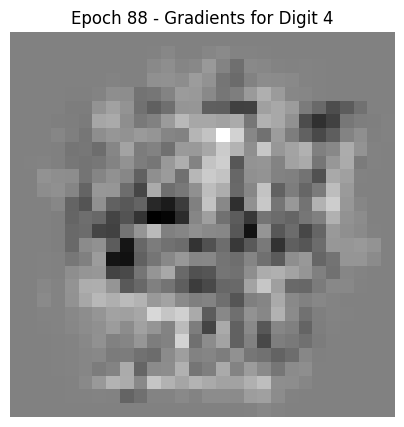

Epoch [89/100], Train Loss: 0.0893, Train Acc: 0.9960, Val Loss: 0.3188, Val Acc: 0.9050


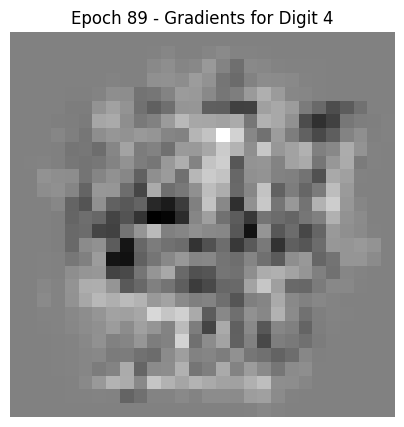

Epoch [90/100], Train Loss: 0.0891, Train Acc: 0.9960, Val Loss: 0.3187, Val Acc: 0.9050


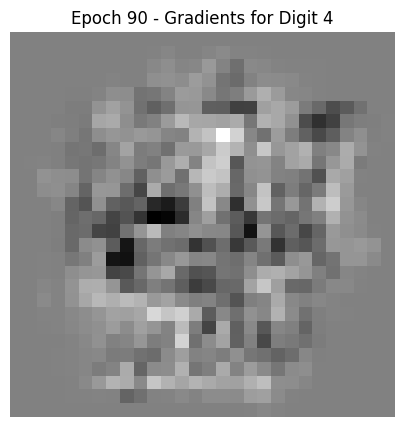

Epoch [91/100], Train Loss: 0.0889, Train Acc: 0.9960, Val Loss: 0.3187, Val Acc: 0.9050


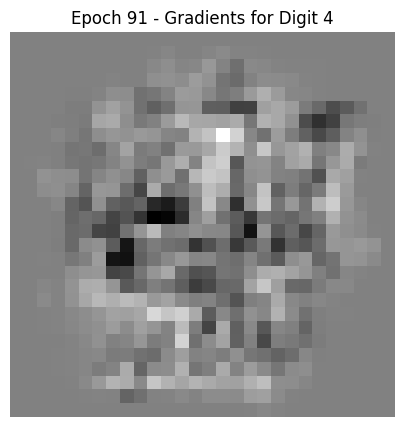

Epoch [92/100], Train Loss: 0.0888, Train Acc: 0.9960, Val Loss: 0.3186, Val Acc: 0.9050


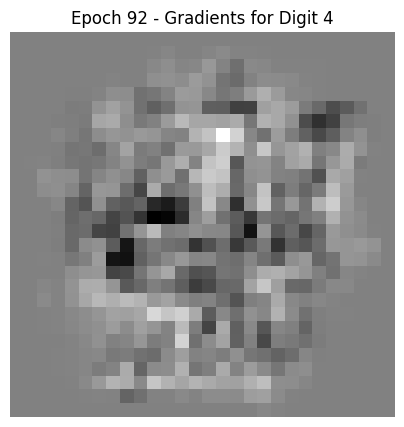

Epoch [93/100], Train Loss: 0.0886, Train Acc: 0.9960, Val Loss: 0.3186, Val Acc: 0.9050


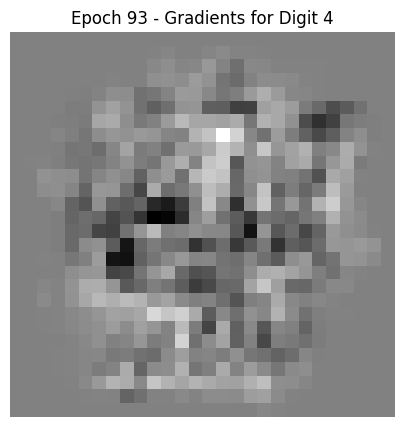

Epoch [94/100], Train Loss: 0.0885, Train Acc: 0.9960, Val Loss: 0.3186, Val Acc: 0.9050


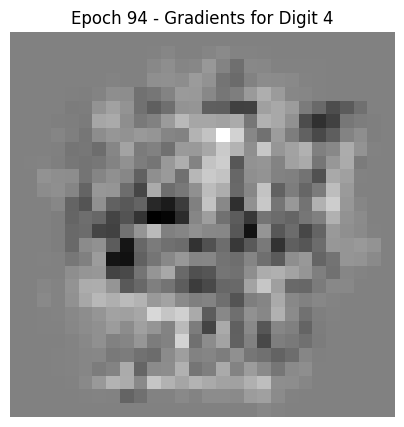

Epoch [95/100], Train Loss: 0.0883, Train Acc: 0.9960, Val Loss: 0.3185, Val Acc: 0.9050


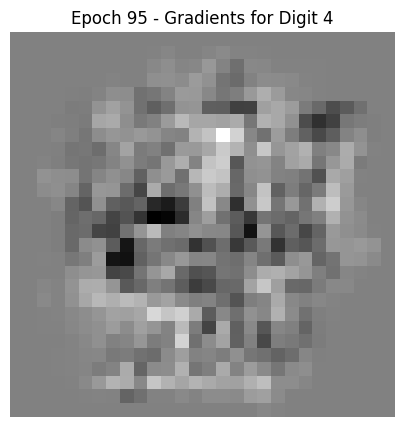

Epoch [96/100], Train Loss: 0.0881, Train Acc: 0.9960, Val Loss: 0.3185, Val Acc: 0.9050


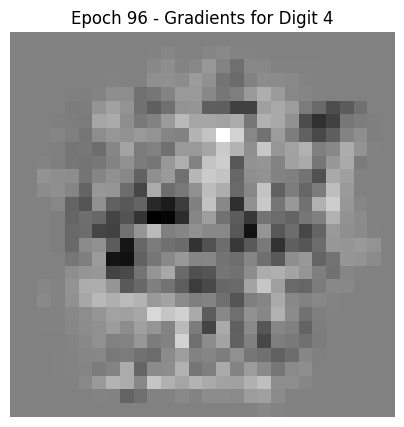

Epoch [97/100], Train Loss: 0.0880, Train Acc: 0.9960, Val Loss: 0.3185, Val Acc: 0.9050


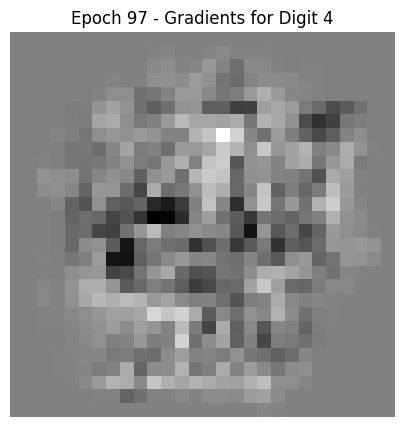

Epoch [98/100], Train Loss: 0.0878, Train Acc: 0.9960, Val Loss: 0.3184, Val Acc: 0.9050


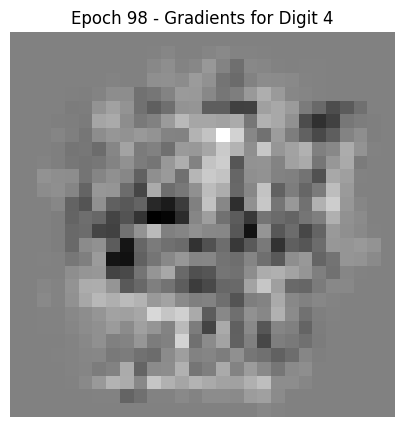

Epoch [99/100], Train Loss: 0.0877, Train Acc: 0.9960, Val Loss: 0.3184, Val Acc: 0.9050


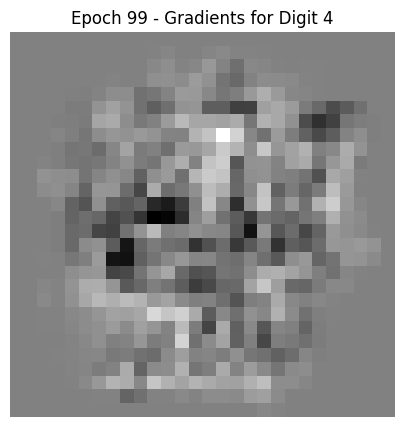

Epoch [100/100], Train Loss: 0.0875, Train Acc: 0.9960, Val Loss: 0.3184, Val Acc: 0.9050


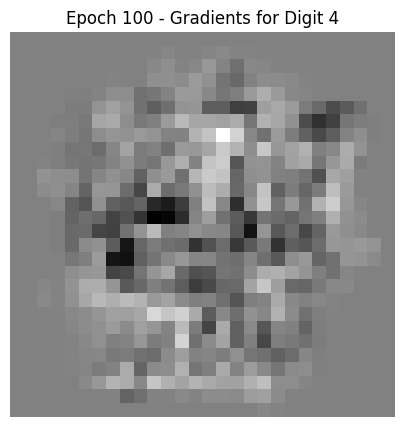

In [23]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

    # Visualização dos gradientes referentes à classe do dígito 4
    if model.weight.grad is not None:
        plt.figure(figsize=(5, 5))
        plt.imshow(model.weight.grad[4, :].cpu().numpy().reshape((28, 28)), cmap='gray')
        plt.title(f'Epoch {i+1} - Gradients for Digit 4')
        plt.axis('off')
        plt.show()


In [14]:
print('Final loss:', loss.item())

Final loss: 0.2643072009086609


### Visualizando gráfico de perda durante o treinamento

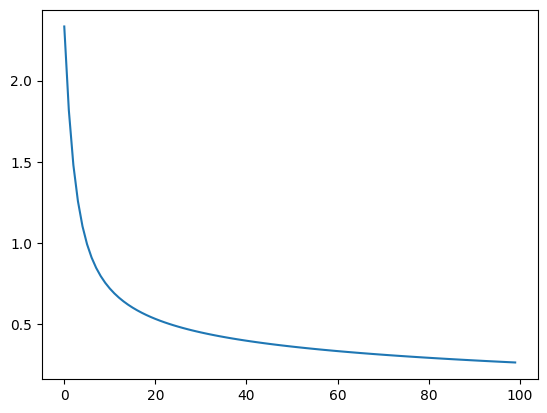

In [15]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

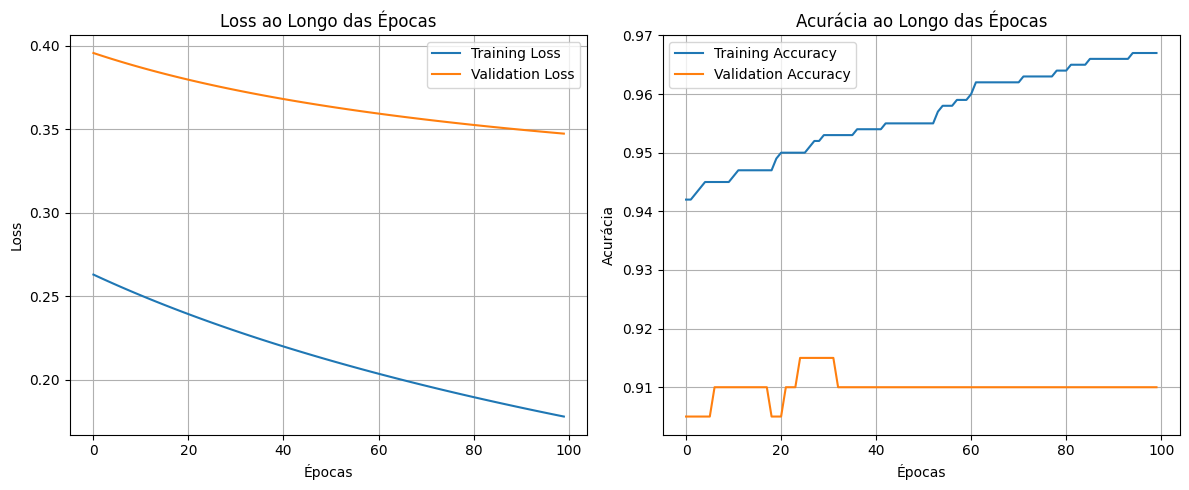

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [17]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.967


### Matriz de confusão com dados de treinamento e teste

In [18]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,1,0
2,0,0,92,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,104,1,0,1,0,2
5,0,2,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,1,2,0,0,0,0,0,85,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


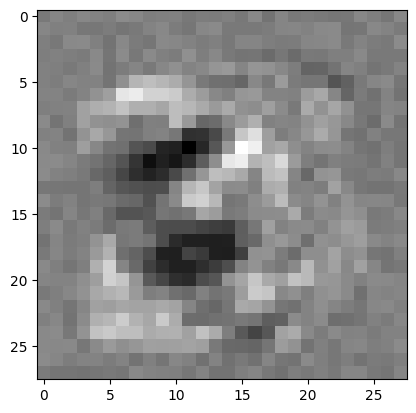

In [19]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

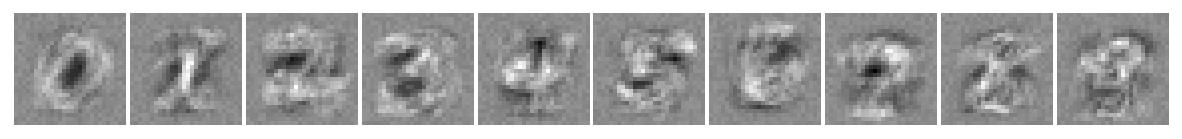

In [20]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede?
2. Qual é o shape da saída da rede?
3. Qual é o número total de parâmetros da rede, incluindo o bias?

# Aprendizados
